In [1]:
pip install pandas matplotlib seaborn scikit-learn


========== FIRST 5 ROWS ==========

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


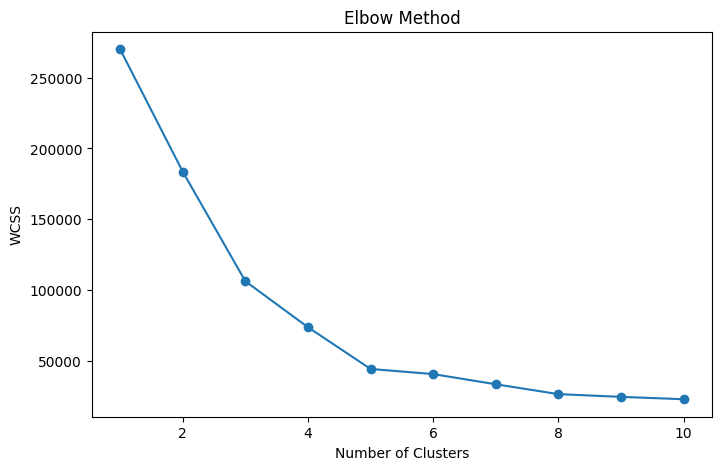

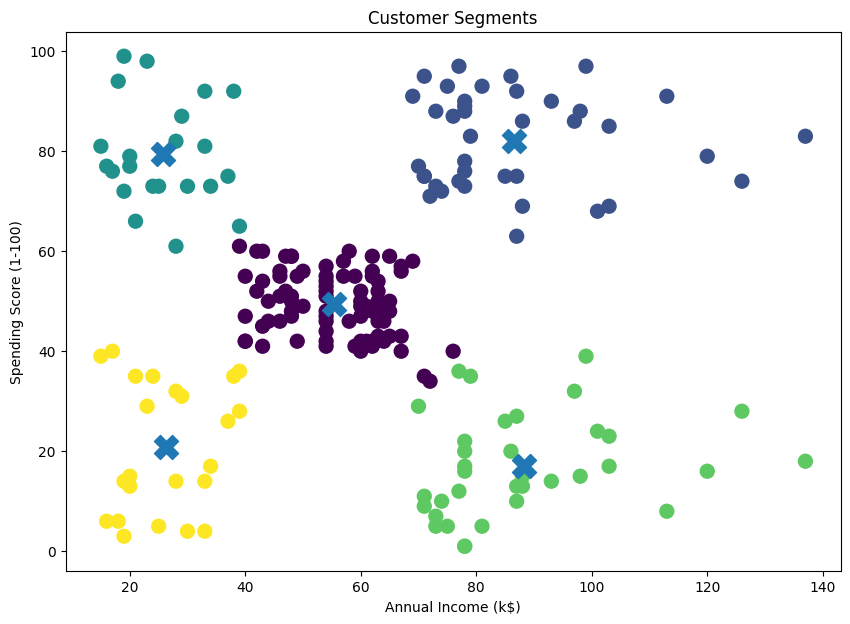


========== CLUSTER CENTERS ==========

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]

Clustered customer data saved successfully.

========== TASK 2 COMPLETED SUCCESSFULLY ==========


In [2]:
# =========================================================
# SKILLCRAFT TECHNOLOGY - TASK 2
# CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
# Repository Name: SCT_ML_2
# =========================================================

# =========================
# IMPORT REQUIRED LIBRARIES
# =========================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("Mall_Customers.csv")

print("\n========== FIRST 5 ROWS ==========\n")
print(df.head())

# =========================
# SELECT FEATURES
# =========================

# Using Annual Income and Spending Score

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# =========================
# FIND BEST NUMBER OF CLUSTERS
# ELBOW METHOD
# =========================

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

# =========================
# VISUALIZE ELBOW METHOD
# =========================

plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.savefig("elbow_method.png")

plt.show()

# =========================
# TRAIN FINAL MODEL
# =========================

kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

# =========================
# VISUALIZE CLUSTERS
# =========================

plt.figure(figsize=(10, 7))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y_kmeans,
    s=100
)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    marker='X'
)

plt.title('Customer Segments')

plt.xlabel('Annual Income (k$)')

plt.ylabel('Spending Score (1-100)')

plt.savefig("customer_clusters.png")

plt.show()

# =========================
# DISPLAY CLUSTER CENTERS
# =========================

print("\n========== CLUSTER CENTERS ==========\n")

print(kmeans.cluster_centers_)

# =========================
# SAVE OUTPUT
# =========================

df['Cluster'] = y_kmeans

df.to_csv("clustered_customers.csv", index=False)

print("\nClustered customer data saved successfully.")

# =========================
# TASK COMPLETED
# =========================

print("\n========== TASK 2 COMPLETED SUCCESSFULLY ==========")